# Machine Learning Model

Machine learning is used in this project to predict the probability of loan default based on applicant and loan characteristics.

The target variable is `loan_status`, where:

* `0` represents a non-default loan
* `1` represents a defaulted loan

The modeling process includes feature selection, categorical encoding, train-test splitting, feature scaling, model training, prediction, and performance evaluation.

Two classification algorithms are implemented:

1. **Logistic Regression** — used as an interpretable baseline classification model.
2. **Random Forest Classifier** — used to capture non-linear relationships between applicant characteristics and default risk.

The models are evaluated using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and a Confusion Matrix.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [2]:
df = pd.read_csv("credit_risk_cleaned.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
df.info()

Shape: (32416, 12)

Columns:
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32416 entries, 0 to 32415
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32416 non-null  int64  
 1   person_income               32416 non-null  int64  
 2   person_home_ownership       32416 non-null  object 
 3   person_emp_length           32416 non-null  int64  
 4   loan_intent                 32416 non-null  object 
 5   loan_grade                  32416 non-null  object 
 6   loan_amnt                   32416 non-null  int64  
 7   loan_int_rate               32416 non-null  float64
 8   loan_status                 32416 non-null  int64  
 

Define Features and Target

The target variable is loan_status.

We exclude the target from the feature set because the model should learn the relationship between applicant/loan characteristics and the target rather than using the answer itself.

In [4]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (32416, 11)
Target shape: (32416,)


In [5]:
# Separate Numerical and Categorical Features
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

Categorical Features:
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


Train-Test Split

We divide the dataset into training and testing sets.

80% → training
20% → testing

Stratification is used so that the proportion of default and non-default cases remains similar in both datasets.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (25932, 11)
Testing set: (6484, 11)


Preprocessing Pipeline

Categorical variables need to be converted into numerical form using One-Hot Encoding.

Numerical variables are standardized for Logistic Regression.

In [7]:
preprocessor = ColumnTransformer(transformers=[("num", StandardScaler(), numerical_features),("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)])

Logistic Regression Model

Logistic Regression estimates the probability of a binary outcome.

Here, the model estimates the probability that a loan will default.

In [9]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))])
logistic_model.fit(X_train, y_train)
y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

In [11]:
# Evaluate Logistic Regression
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)
print("Logistic Regression:")
print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1-Score :", round(lr_f1, 4))
print("ROC-AUC  :", round(lr_auc, 4))

Logistic Regression:
Accuracy : 0.8151
Precision: 0.5556
Recall   : 0.7722
F1-Score : 0.6462
ROC-AUC  : 0.8696


For credit-risk prediction, Recall is particularly important because missing an actual default can be costly.

Precision indicates how many loans predicted as default were actually defaults.

F1-Score balances Precision and Recall.

ROC-AUC measures the model's ability to distinguish between default and non-default cases across classification thresholds.

In [12]:
# Classification Report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.93      0.83      0.87      5066
           1       0.56      0.77      0.65      1418

    accuracy                           0.82      6484
   macro avg       0.74      0.80      0.76      6484
weighted avg       0.85      0.82      0.82      6484



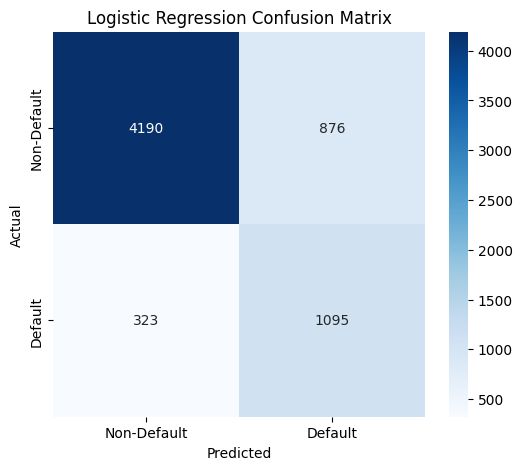

In [13]:
# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Default", "Default"],
    yticklabels=["Non-Default", "Default"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

The confusion matrix contains:

True Negative — correctly predicted non-default
True Positive — correctly predicted default
False Positive — non-default predicted as default
False Negative — default predicted as non-default
5.13 Random Forest Classifier

Random Forest combines multiple decision trees to produce a stronger classification model.

It can capture non-linear relationships and interactions between applicant and loan characteristics.

In [14]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]
)
random_forest_model.fit(X_train, y_train)
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [15]:
# Evaluate Random Forest
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)
print("Random Forest")
print("-------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1-Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_auc, 4))

Random Forest
-------------
Accuracy : 0.9329
Precision: 0.9712
Recall   : 0.7144
F1-Score : 0.8232
ROC-AUC  : 0.933


In [16]:
# Random Forest Classification Report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5066
           1       0.97      0.71      0.82      1418

    accuracy                           0.93      6484
   macro avg       0.95      0.85      0.89      6484
weighted avg       0.94      0.93      0.93      6484



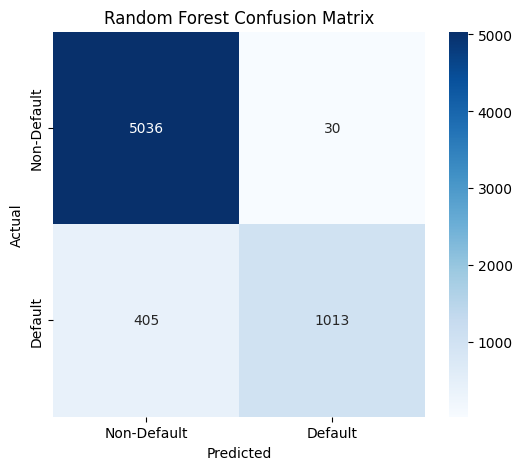

In [17]:
# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Default", "Default"],
    yticklabels=["Non-Default", "Default"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [18]:
# Compare the Models
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_accuracy, rf_accuracy],
    "Precision": [lr_precision, rf_precision],
    "Recall": [lr_recall, rf_recall],
    "F1-Score": [lr_f1, rf_f1],
    "ROC-AUC": [lr_auc, rf_auc]
})
model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8151,0.5556,0.7722,0.6462,0.8696
1,Random Forest,0.9329,0.9712,0.7144,0.8232,0.9330


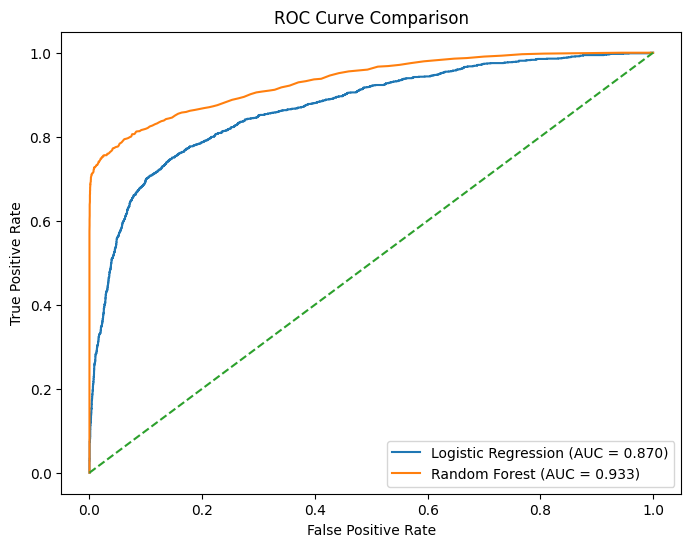

In [19]:
# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.figure(figsize=(8, 6))
plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {lr_auc:.3f})"
)
plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [20]:
#Feature Importance — Random Forest

#This is useful for explaining which variables contribute most strongly to the Random Forest's predictions.

rf_pipeline = random_forest_model.named_steps["model"]
rf_preprocessor = random_forest_model.named_steps["preprocessor"]
encoded_columns = rf_preprocessor.get_feature_names_out()
feature_importance = pd.DataFrame({
    "Feature": encoded_columns,
    "Importance": rf_pipeline.feature_importances_
})
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)
feature_importance.head(15)

,Feature,Importance
5,num__loan_percent_income,0.201705
1,num__person_income,0.157106
4,num__loan_int_rate,0.130919
3,num__loan_amnt,0.078898
2,num__person_emp_length,0.054518
20,cat__loan_grade_D,0.052436
0,num__person_age,0.048857
10,cat__person_home_ownership_RENT,0.040808
6,num__cb_person_cred_hist_length,0.038852
17,cat__loan_grade_A,0.021557


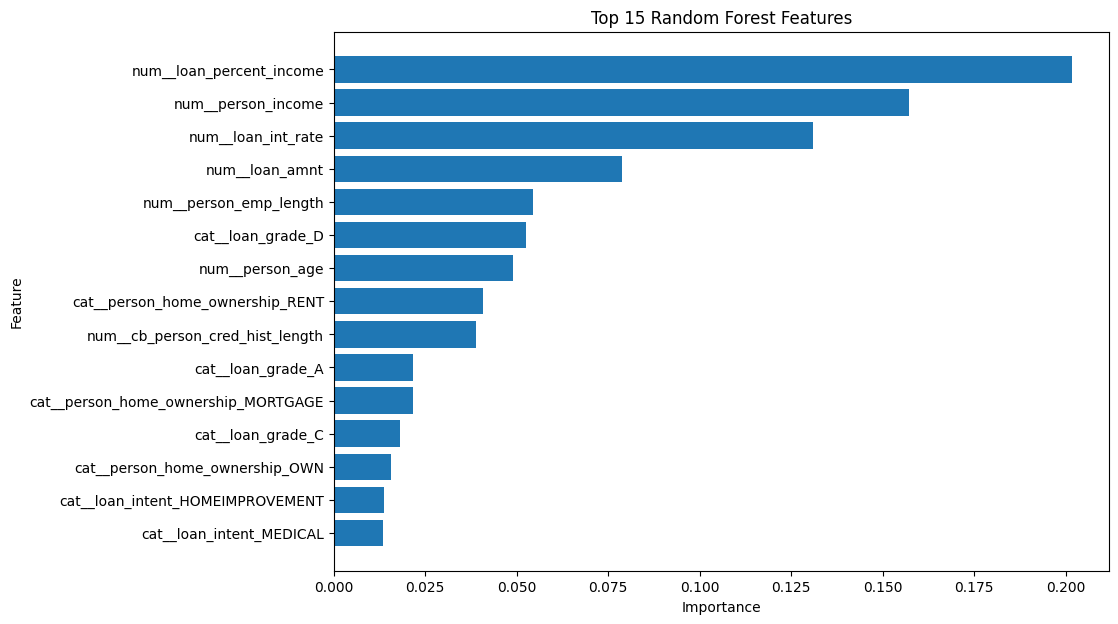

In [21]:
#  Visualize the top features:

top_features = feature_importance.head(15).sort_values("Importance")
plt.figure(figsize=(10, 7))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Features")
plt.show()

In [22]:
# Generate Default Probabilities

#For a credit-risk system, probability estimates are more useful than simply producing a 0/1 prediction.

risk_output = X_test.copy()
risk_output["Actual_Status"] = y_test.values
risk_output["Predicted_Status"] = y_pred_rf
risk_output["Default_Probability"] = y_prob_rf
risk_output.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,Actual_Status,Predicted_Status,Default_Probability
21156,28,56461,RENT,5,EDUCATION,E,5400,15.68,0.10,Y,6,0,0,0.443333
26854,30,108000,MORTGAGE,0,DEBTCONSOLIDATION,B,4925,10.99,0.05,N,9,1,0,0.100000
26333,29,102000,OWN,10,MEDICAL,B,18000,9.33,0.18,N,7,0,0,0.003333
24056,29,45000,RENT,4,VENTURE,B,10000,12.42,0.22,N,7,0,0,0.010000
24947,31,30000,RENT,4,DEBTCONSOLIDATION,B,12000,10.39,0.40,N,9,1,1,1.000000


In [23]:
# reate Risk Probability Bands

#These are project-defined probability bands, not official banking risk grades.

risk_output["Risk_Band"] = pd.cut(
    risk_output["Default_Probability"],
    bins=[0, 0.25, 0.50, 0.75, 1.00],
    labels=["Low Probability", "Moderate Probability", "High Probability", "Very High Probability"],
    include_lowest=True
)
risk_output["Risk_Band"].value_counts().sort_index()

,count
Risk_Band,
Low Probability,5081
Moderate Probability,360
High Probability,108
Very High Probability,935


In [24]:
# Save ML Results
risk_output.to_csv("/content/credit_risk_ml_predictions.csv",index=False)
model_comparison.to_csv("/content/model_comparison.csv",index=False)
feature_importance.to_csv("/content/random_forest_feature_importance.csv",index=False)
print("ML results saved successfully.")

ML results saved successfully.


# Conclusion

The machine learning stage transformed the cleaned credit dataset into a predictive credit-risk modeling framework.

* The target variable `loan_status` was used to classify loans into default and non-default categories.
* Logistic Regression was implemented as an interpretable baseline classification model.
* Random Forest was implemented to capture non-linear relationships and interactions among applicant and loan characteristics.
* The models were evaluated using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Confusion Matrix.
* ROC curves were used to compare the models' ability to distinguish between default and non-default loans.
* Random Forest feature importance was analyzed to identify variables that contributed strongly to model predictions.
* Default probabilities were generated to provide a more granular view of potential credit risk.
* Probability bands were created for analytical segmentation; these bands are project-defined and should not be interpreted as official lending decisions.
* The resulting predictions and model outputs were exported for integration with the SQL analysis and Power BI dashboard.

Overall, the machine learning stage adds predictive analytics to the platform while maintaining a clear separation between exploratory risk analysis, model-based prediction, and business reporting.
